<a href="https://colab.research.google.com/github/jeandirel/NLP/blob/main/RNN_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We will then define the weights of the network:

Step 2.3: Start actual training

We will now start with the actual training of the network. In this, we will first do a forward pass to calculate the errors and a backward pass to calculate the gradients and update them. Let me show you these step-by-step so you can visualize how it works in your mind.

In [1]:
import torch
import torch.nn as nn

# ----------------------------
# Parameters
# ----------------------------
input_size = 5     # Size of each input vector
hidden_size = 10   # Size of hidden state
output_size = 2    # Size of the output vector
seq_length = 7     # Length of input sequence
batch_size = 1     # Number of sequences in a batch

# ----------------------------
# Sample Input: [batch_size, seq_length, input_size]
# ----------------------------
x = torch.randn(batch_size, seq_length, input_size)  # Random input sequence

# ----------------------------
# Define a Simple RNN Model
# ----------------------------
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)  # Map hidden state to output

    def forward(self, x):
        # x: [batch_size, seq_length, input_size]
        out, h_n = self.rnn(x)      # out: [batch_size, seq_length, hidden_size]
        last_hidden = out[:, -1, :] # Get hidden state at last time step
        out = self.fc(last_hidden)  # out: [batch_size, output_size]
        return out

# ----------------------------
# Instantiate and Run the Model
# ----------------------------
model = SimpleRNN(input_size, hidden_size, output_size)
output = model(x)

print("Input shape:", x.shape)        # [1, 7, 5]
print("Output shape:", output.shape)  # [1, 2]


Input shape: torch.Size([1, 7, 5])
Output shape: torch.Size([1, 2])


The RNN in the code above is a simple sequence-processing model that takes a sequence of input vectors and produces a single output vector based on the entire sequence.

What the RNN Does (Conceptually)
Input: A sequence of vectors (length = 7, vector size = 5).
Think of it as a time-series or sentence with 7 tokens, each represented by a 5-dimensional feature vector.

Processing:

The RNN reads one input vector at a time (from
t=1 to 7), updating its internal hidden state.

At each step, it combines the current input with the previous hidden state.

Final Step:

After the last time step, the RNN takes the final hidden state ℎ7 and passes it through a fully connected layer to produce the output.

Output: A single vector of size 2 — for example, this could represent:

Class scores (e.g., binary classification),

Regression targets (e.g., predicting two continuous values),

Any task where the entire input sequence maps to one result.



## Tesla stock price prediction

RNN Model Construction:
* A Sequential model was created using Keras.
* Multiple layers of SimpleRNN were added to the model, each with 50 units and tanh activation function.
* Dropout layers were included to prevent overfitting by randomly setting a fraction of input units to 0 at each update during training.
* A Dense layer with a single neuron was added as the output layer to predict the stock price.

## Coding activity

* In this project, we build a Recurrent Neural Network (RNN) to predict Tesla’s stock prices using historical data.

* Perform data preprocessing, scaled the data, created input sequences, built and trained an RNN model, and visualized the results.

* The predictions made by the RNN model closely follow the actual stock prices, demonstrating the effectiveness of RNNs for time series prediction tasks.

/tmp/ipython-input-2-591469409.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2020-01-01", end="2023-12-08")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.2155
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0397
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0112
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0062
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0030
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0030
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0023
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0022
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0021
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0020
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0019
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0019
Epoch 13/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0019
Epoch 14/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0018
Epoch 15/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0018
Epo

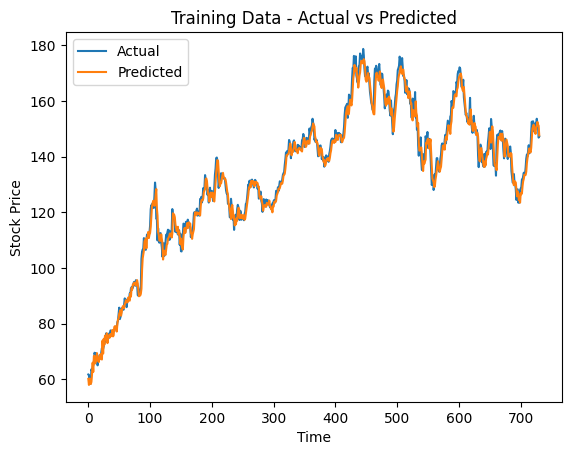

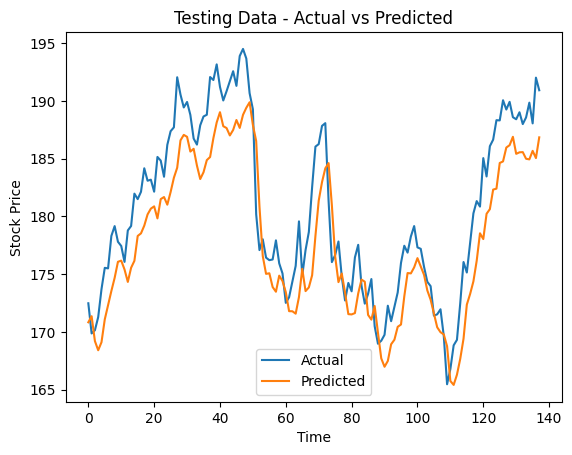

In [2]:
import yfinance as yf
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Download historical stock data (e.g., Apple)
data = yf.download("AAPL", start="2020-01-01", end="2023-12-08")
data = data[["Close"]]  # Use only closing price

# Normalize data
scaler = MinMaxScaler()
data["Close"] = scaler.fit_transform(np.array(data["Close"]).reshape(-1, 1))

# Split data into training and testing sets
train_size = int(len(data) * 0.8)
train_data, test_data = data[:train_size], data[train_size:]

# Create dataset with lookback period (e.g., 60 days)
def create_dataset(dataset, look_back=60):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        a = dataset['Close'][i:(i + look_back)].values  # Access 'Close' column and convert to NumPy array
        X.append(a)
        # Access 'Close' column by name using .iloc for integer-based indexing
        Y.append(dataset['Close'].iloc[i + look_back])
    return np.array(X), np.array(Y)

look_back = 60
X_train, Y_train = create_dataset(train_data, look_back)
X_test, Y_test = create_dataset(test_data, look_back)

# Reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Create RNN model
model = Sequential()
model.add(SimpleRNN(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(SimpleRNN(units=50))
model.add(Dense(1))

# Compile model
model.compile(loss='mean_squared_error', optimizer='adam')

# Train model
model.fit(X_train, Y_train, epochs=100, batch_size=64, verbose=1)

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Invert predictions to original scale
train_predict = scaler.inverse_transform(train_predict)
Y_train = scaler.inverse_transform(Y_train.reshape(-1, 1))  # Reshape Y_train before inverse transform
test_predict = scaler.inverse_transform(test_predict)
Y_test = scaler.inverse_transform(Y_test.reshape(-1, 1))  # Reshape Y_test before inverse transform

# Evaluate the model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

# Calculate root mean squared error (RMSE)
train_rmse = math.sqrt(mean_squared_error(Y_train, train_predict))
test_rmse = math.sqrt(mean_squared_error(Y_test, test_predict))
print('Train RMSE: %.3f' % (train_rmse))
print('Test RMSE: %.3f' % (test_rmse))

# Calculate mean absolute error (MAE)
train_mae = mean_absolute_error(Y_train, train_predict)
test_mae = mean_absolute_error(Y_test, test_predict)
print('Train MAE: %.3f' % (train_mae))
print('Test MAE: %.3f' % (test_mae))

# Plot the results
import matplotlib.pyplot as plt

# Plot the training data and predictions
plt.plot(Y_train, label='Actual')
plt.plot(train_predict, label='Predicted')
plt.title('Training Data - Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

# Plot the testing data and predictions
plt.plot(Y_test, label='Actual')
plt.plot(test_predict, label='Predicted')
plt.title('Testing Data - Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

https://medium.com/thedeephub/rnns-in-action-predicting-stock-prices-with-recurrent-neural-networks-9155a33c4c3b

## Improve accuracy by varying number of hidden layers

/tmp/ipython-input-6-101034790.py:59: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2020-01-01", end="2023-12-08")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training with units=70, epochs=200, batch_size=32
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

Parameters: {'look_back': 30, 'units': 70, 'epochs': 200, 'batch_size': 32}
Train RMSE: 2.774
Test RMSE: 3.251


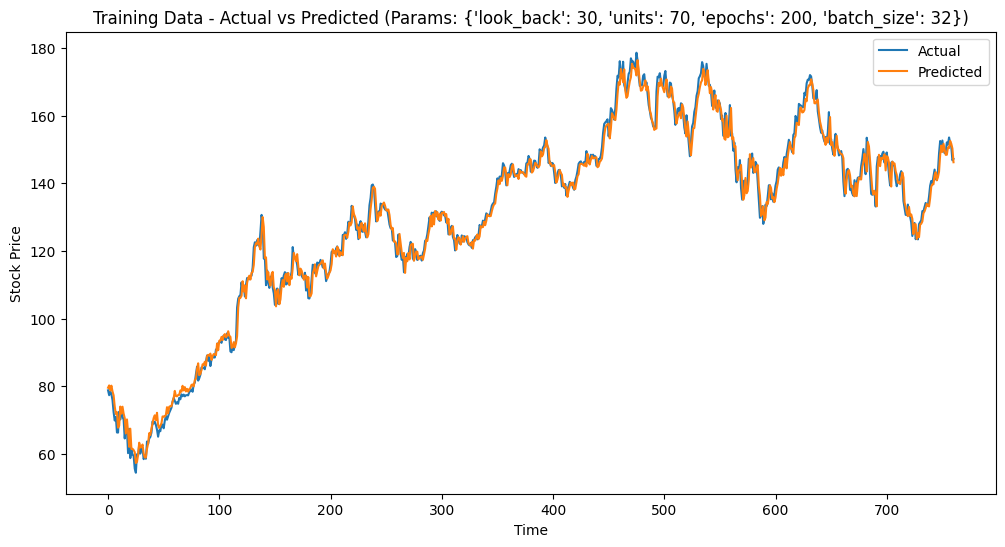

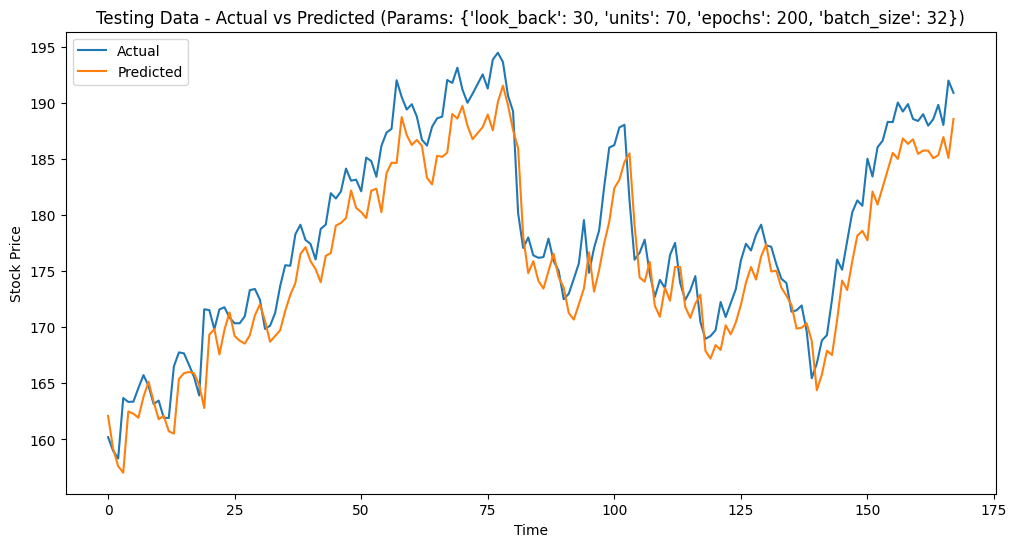

In [6]:
# prompt: Change RNN parameters and post results (plot +RMSE) and which parameters you used

# Function to create and train the RNN model with varying parameters
def train_and_evaluate_rnn(data, look_back, units, epochs, batch_size):
  # Normalize data
  scaler = MinMaxScaler()
  data["Close"] = scaler.fit_transform(np.array(data["Close"]).reshape(-1, 1))

  # Split data into training and testing sets
  train_size = int(len(data) * 0.8)
  train_data, test_data = data[:train_size], data[train_size:]

  # Create dataset with lookback period
  def create_dataset(dataset, look_back=60):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        a = dataset['Close'][i:(i + look_back)].values
        X.append(a)
        Y.append(dataset['Close'].iloc[i + look_back])
    return np.array(X), np.array(Y)

  X_train, Y_train = create_dataset(train_data, look_back)
  X_test, Y_test = create_dataset(test_data, look_back)

  # Reshape input to be [samples, time steps, features]
  X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
  X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

  # Create RNN model
  model = Sequential()
  model.add(SimpleRNN(units=units, return_sequences=True, input_shape=(X_train.shape[1], 1)))
  model.add(SimpleRNN(units=units))
  model.add(Dense(1))

  # Compile model
  model.compile(loss='mean_squared_error', optimizer='adam')

  # Train model
  print(f"Training with units={units}, epochs={epochs}, batch_size={batch_size}")
  history = model.fit(X_train, Y_train, epochs=epochs, batch_size=batch_size, verbose=0) # Set verbose to 0 to reduce output during tuning

  # Make predictions
  train_predict = model.predict(X_train)
  test_predict = model.predict(X_test)

  # Invert predictions to original scale
  train_predict = scaler.inverse_transform(train_predict)
  Y_train = scaler.inverse_transform(Y_train.reshape(-1, 1))
  test_predict = scaler.inverse_transform(test_predict)
  Y_test = scaler.inverse_transform(Y_test.reshape(-1, 1))

  # Calculate RMSE
  train_rmse = math.sqrt(mean_squared_error(Y_train, train_predict))
  test_rmse = math.sqrt(mean_squared_error(Y_test, test_predict))

  return train_rmse, test_rmse, Y_train, train_predict, Y_test, test_predict, history

# Download historical stock data (e.g., Apple)
data = yf.download("AAPL", start="2020-01-01", end="2023-12-08")
initial_data = data[["Close"]].copy() # Use a copy to avoid modifying the original data

# Define different sets of parameters to test
parameter_sets = [
    # {'look_back': 60, 'units': 30, 'epochs': 50, 'batch_size': 32},
    # {'look_back': 60, 'units': 70, 'epochs': 150, 'batch_size': 128},
    # {'look_back': 90, 'units': 50, 'epochs': 100, 'batch_size': 64},
    {'look_back': 30, 'units': 70, 'epochs': 200, 'batch_size': 32},
]

results = []

for params in parameter_sets:
    train_rmse, test_rmse, Y_train, train_predict, Y_test, test_predict, history = train_and_evaluate_rnn(
        initial_data.copy(), # Pass a copy of the original data
        params['look_back'],
        params['units'],
        params['epochs'],
        params['batch_size']
    )
    results.append({
        'parameters': params,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'Y_train': Y_train,
        'train_predict': train_predict,
        'Y_test': Y_test,
        'test_predict': test_predict
    })

# Print results and plot for each parameter set
for result in results:
    print("\n" + "="*30)
    print("Parameters:", result['parameters'])
    print('Train RMSE: %.3f' % (result['train_rmse']))
    print('Test RMSE: %.3f' % (result['test_rmse']))
    print("="*30)

    # Plot the training data and predictions
    plt.figure(figsize=(12, 6))
    plt.plot(result['Y_train'], label='Actual')
    plt.plot(result['train_predict'], label='Predicted')
    plt.title(f"Training Data - Actual vs Predicted (Params: {result['parameters']})")
    plt.xlabel('Time')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()

    # Plot the testing data and predictions
    plt.figure(figsize=(12, 6))
    plt.plot(result['Y_test'], label='Actual')
    plt.plot(result['test_predict'], label='Predicted')
    plt.title(f"Testing Data - Actual vs Predicted (Params: {result['parameters']})")
    plt.xlabel('Time')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.show()


/tmp/ipython-input-7-1237332024.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download('AAPL', start='2010-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training with params: {'look_back': 60, 'units': 30, 'epochs': 50, 'batch_size': 32}
Training with params: {'look_back': 60, 'units': 70, 'epochs': 150, 'batch_size': 128}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training with params: {'look_back': 90, 'units': 50, 'epochs': 100, 'batch_size': 64}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training with params: {'look_back': 30, 'units': 70, 'epochs': 200, 'batch_size': 32}


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Parameters: {'look_back': 60, 'units': 30, 'epochs': 50, 'batch_size': 32}
Train RMSE: 1.431
Test  RMSE: 3.088


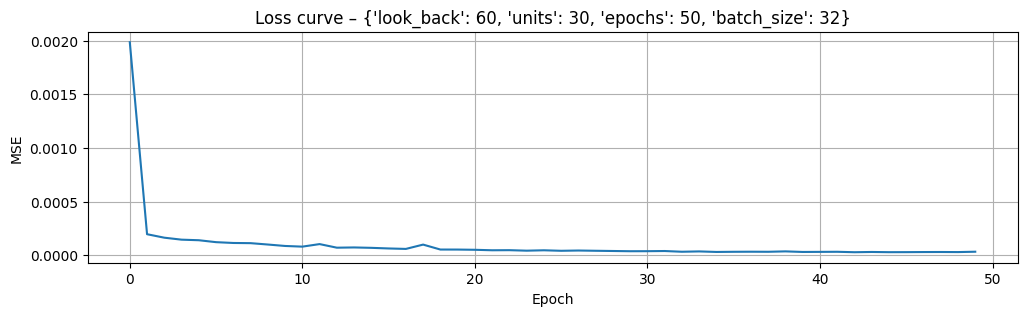

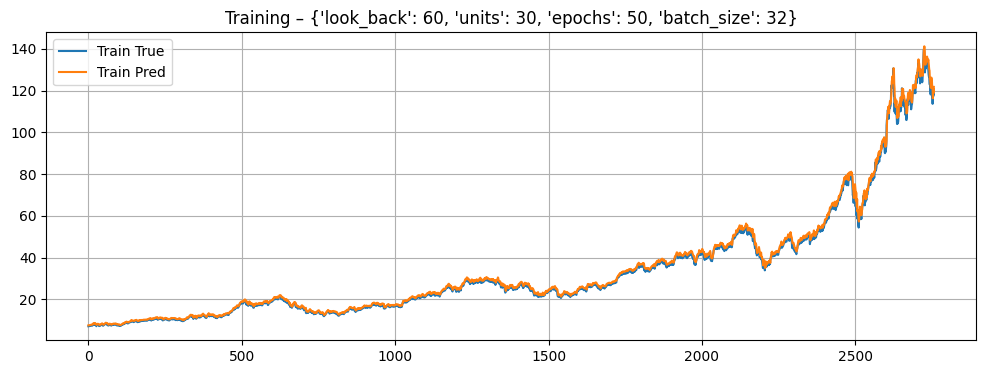

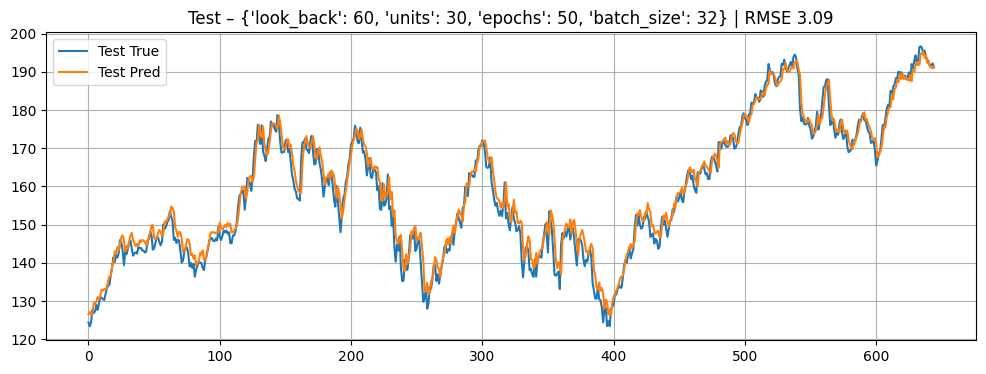


Parameters: {'look_back': 60, 'units': 70, 'epochs': 150, 'batch_size': 128}
Train RMSE: 0.922
Test  RMSE: 3.088


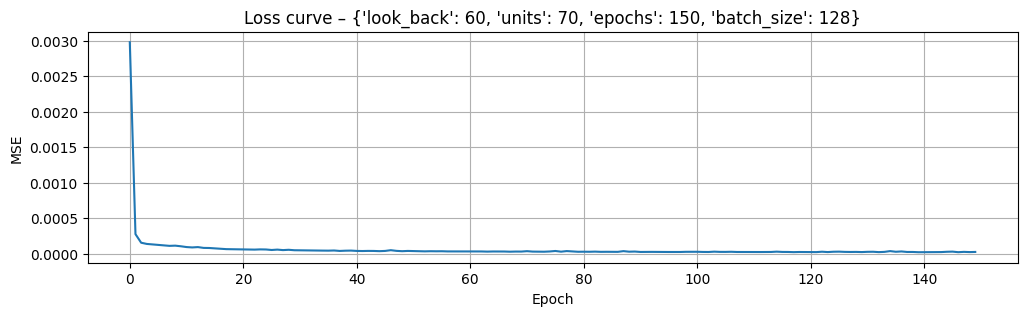

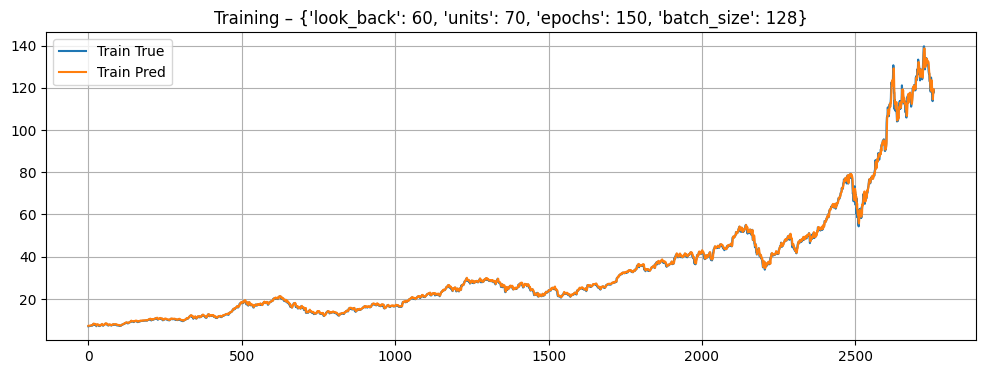

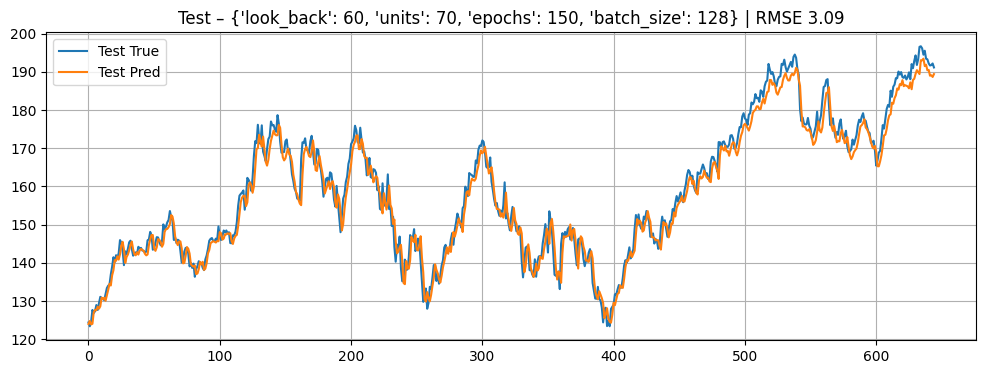


Parameters: {'look_back': 90, 'units': 50, 'epochs': 100, 'batch_size': 64}
Train RMSE: 1.124
Test  RMSE: 8.872


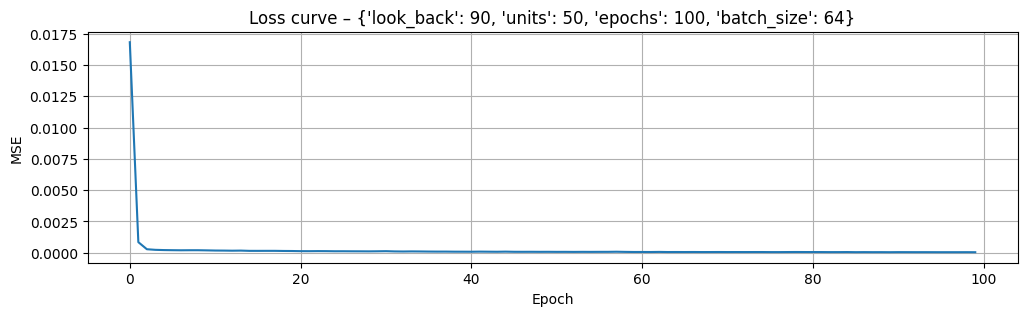

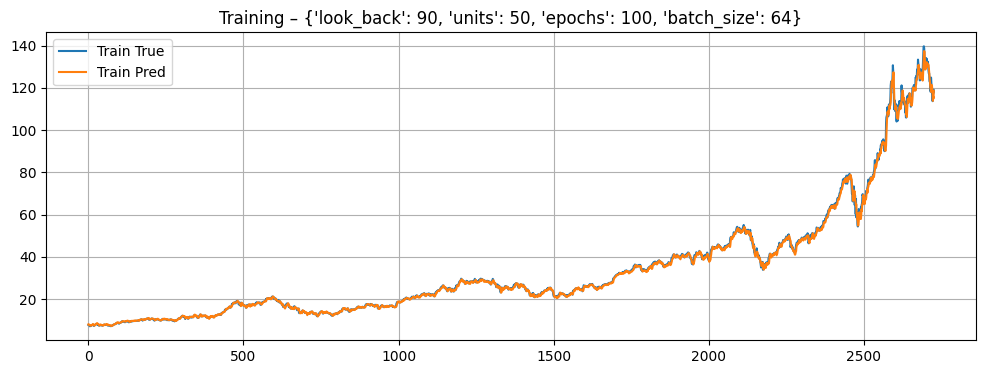

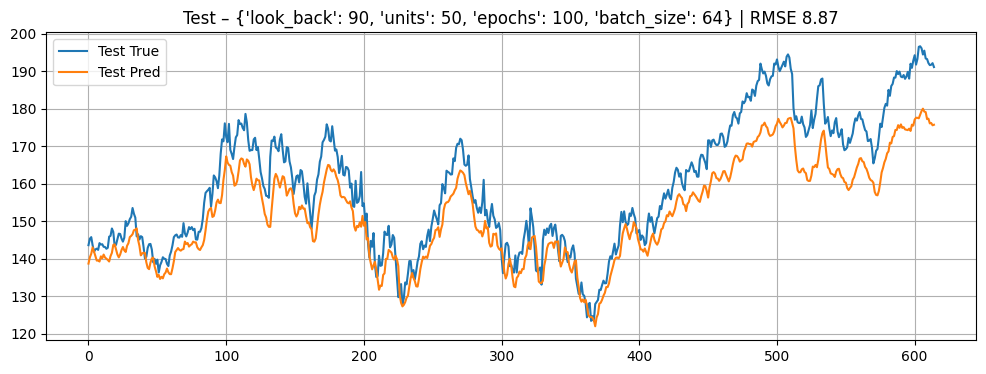


Parameters: {'look_back': 30, 'units': 70, 'epochs': 200, 'batch_size': 32}
Train RMSE: 0.993
Test  RMSE: 4.195


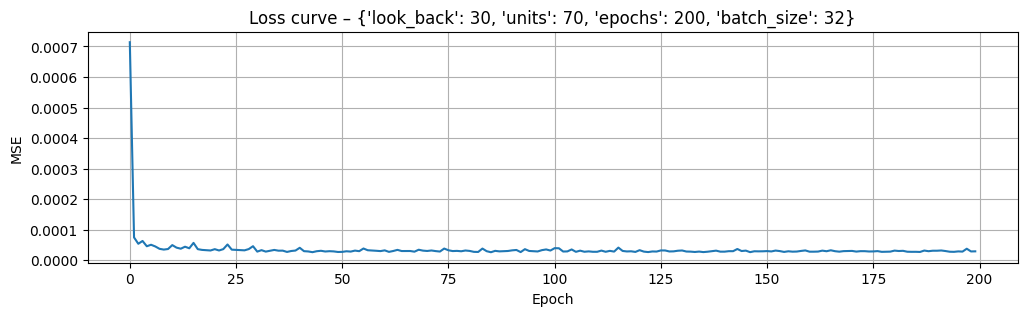

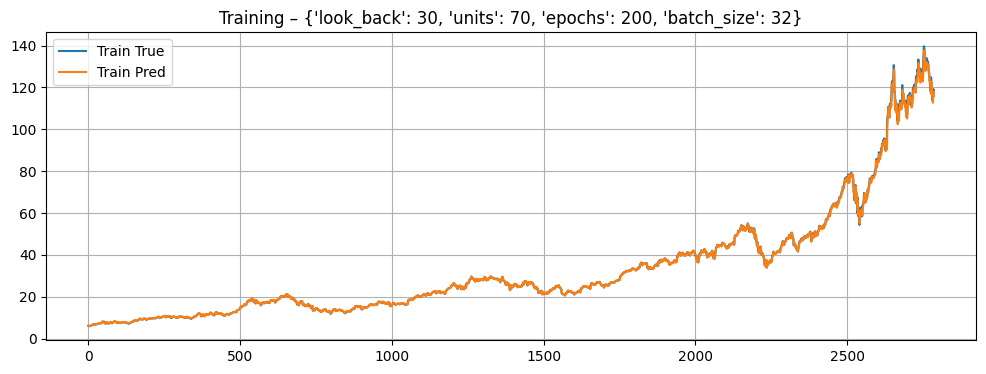

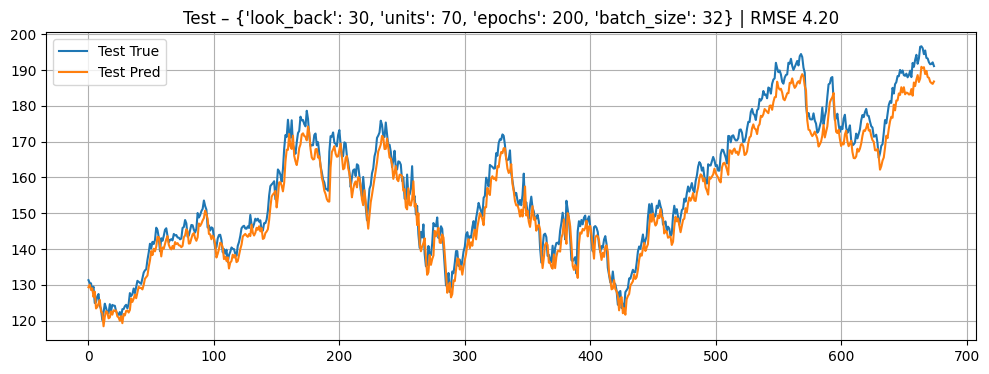

In [7]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

"""
Stock price prediction for AAPL with a SimpleRNN
Now supports multiple hyper‑parameter sets in a loop.
Plots & RMSE for each configuration.
"""

# 🔄 0. Parameter sets to explore
parameter_sets = [
    {'look_back': 60, 'units': 30, 'epochs': 50,  'batch_size': 32},
    {'look_back': 60, 'units': 70, 'epochs': 150, 'batch_size': 128},
    {'look_back': 90, 'units': 50, 'epochs': 100, 'batch_size': 64},
    {'look_back': 30, 'units': 70, 'epochs': 200, 'batch_size': 32},
]

# 1️⃣ Download close prices once
stock_data = yf.download('AAPL', start='2010-01-01', end='2023-12-31')
close_prices = stock_data['Close'].values.reshape(-1, 1)

# 2️⃣ Scale data once
scaler = MinMaxScaler()
scaled_all = scaler.fit_transform(close_prices)

# 3️⃣ Helper fn: create sequences
def create_sequences(dataset, look_back):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:i + look_back, 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

# 4️⃣ Helper fn: train & evaluate
def train_and_evaluate_rnn(scaled_data, look_back, units, epochs, batch_size):
    train_size = int(len(scaled_data) * 0.8)
    train, test = scaled_data[:train_size], scaled_data[train_size:]

    X_train, y_train = create_sequences(train, look_back)
    X_test,  y_test  = create_sequences(test,  look_back)

    X_train = X_train.reshape(-1, look_back, 1)
    X_test  = X_test.reshape(-1, look_back, 1)

    model = Sequential([
        SimpleRNN(units, input_shape=(look_back, 1)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

    train_pred = model.predict(X_train, verbose=0)
    test_pred  = model.predict(X_test,  verbose=0)

    # inverse scaling
    train_pred_inv = scaler.inverse_transform(train_pred)
    test_pred_inv  = scaler.inverse_transform(test_pred)
    y_train_inv    = scaler.inverse_transform(y_train.reshape(-1,1))
    y_test_inv     = scaler.inverse_transform(y_test.reshape(-1,1))

    train_rmse = np.sqrt(mean_squared_error(y_train_inv, train_pred_inv))
    test_rmse  = np.sqrt(mean_squared_error(y_test_inv,  test_pred_inv))

    return train_rmse, test_rmse, y_train_inv, train_pred_inv, y_test_inv, test_pred_inv, history.history['loss']

# 5️⃣ Main loop over parameter sets
results = []
for params in parameter_sets:
    print(f"Training with params: {params}")
    res = train_and_evaluate_rnn(
        scaled_all.copy(),
        params['look_back'],
        params['units'],
        params['epochs'],
        params['batch_size']
    )
    results.append({
        'parameters': params,
        'train_rmse': res[0],
        'test_rmse':  res[1],
        'Y_train':    res[2],
        'train_pred': res[3],
        'Y_test':     res[4],
        'test_pred':  res[5],
        'loss_curve': res[6]
    })

# 6️⃣ Report & plots
for r in results:
    print("\n" + "="*40)
    print("Parameters:", r['parameters'])
    print(f"Train RMSE: {r['train_rmse']:.3f}")
    print(f"Test  RMSE: {r['test_rmse']:.3f}")
    print("="*40)

    # plot loss curve
    plt.figure(figsize=(12,3))
    plt.plot(r['loss_curve'])
    plt.title(f"Loss curve – {r['parameters']}")
    plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.grid(True)
    plt.show()

    # training predictions
    plt.figure(figsize=(12,4))
    plt.plot(r['Y_train'], label='Train True')
    plt.plot(r['train_pred'], label='Train Pred')
    plt.title(f"Training – {r['parameters']}")
    plt.legend(); plt.grid(True); plt.show()

    # test predictions
    plt.figure(figsize=(12,4))
    plt.plot(r['Y_test'], label='Test True')
    plt.plot(r['test_pred'], label='Test Pred')
    plt.title(f"Test – {r['parameters']} | RMSE {r['test_rmse']:.2f}")
    plt.legend(); plt.grid(True); plt.show()
